Task 1

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

In [47]:
# load the mnist dataset

(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [48]:
# understand the data
print("Training Images Shape :", x_train.shape)
print("Training Labels Shape :", y_train.shape)

print("Testing Images Shape :", x_test.shape)
print("Testing Labels Shape :", y_test.shape)

Training Images Shape : (60000, 28, 28)
Training Labels Shape : (60000,)
Testing Images Shape : (10000, 28, 28)
Testing Labels Shape : (10000,)


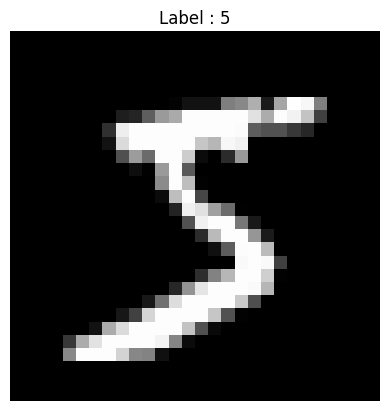

In [49]:
plt.imshow(x_train[0], cmap='gray')
plt.title(f"Label : {y_train[0]}")
plt.axis('off')
plt.show()


In [50]:
# Pixel values are from 0 to 255
# We divide by 255 to convert them between 0 and 1

x_train = x_train / 255.0
x_test = x_test / 255.0

In [51]:
# flatten the dataset 
x_train = x_train.reshape(x_train.shape[0], 784)
x_test = x_test.reshape(x_test.shape[0], 784)


print("x_train shape :", x_train.shape)
print("x_test shape :", x_test.shape)


x_train shape : (60000, 784)
x_test shape : (10000, 784)


In [52]:
# define the architecture ;
input = 784
hidden = 128 
output = 10

In [53]:
# weights and biases 
w1 = np.random.randn(input,hidden) * 0.01
b1 = np.zeros((1, hidden))

w2 = np.random.randn(hidden, output) * 0.01
b2 = np.zeros((1, output))

print(w1.shape)
print(w2.shape)
print(b1.shape)
print(b2.shape)


(784, 128)
(128, 10)
(1, 128)
(1, 10)


In [54]:
# define relu function
def relu(x):
    return np.maximum(0, x)

In [55]:
def softmax(x):

    # Numerical Stability Trick
    x = x - np.max(x, axis=1, keepdims=True)

    exp_x = np.exp(x)

    probabilities = exp_x / np.sum(exp_x, axis=1, keepdims=True)

    return probabilities


In [56]:
# forward pass
X_sample = x_train[:5]

# input to hidden
Z1 = np.dot(X_sample, w1) + b1

print("\nZ1 Shape :", Z1.shape)

# relu function
A1 = relu(Z1)

print("A1 Shape :", A1.shape)

# hidden to output
Z2 = np.dot(A1, w2) + b2

print("Z2 Shape :", Z2.shape)

# softmax fun
output_probabilities = softmax(Z2)

print("Output Probabilities Shape :", output_probabilities.shape)

# final probability
print(output_probabilities)

# final prediction
predictions = np.argmax(output_probabilities, axis=1)

print("\nPredicted Digits :", predictions)
print("True Labels      :", y_train[:5])



Z1 Shape : (5, 128)
A1 Shape : (5, 128)
Z2 Shape : (5, 10)
Output Probabilities Shape : (5, 10)
[[0.09971218 0.09986919 0.09965751 0.10053423 0.10040903 0.09938299
  0.10154115 0.09902296 0.0998442  0.10002656]
 [0.1008911  0.09861217 0.10011888 0.10135012 0.09963804 0.09923462
  0.10061158 0.10008571 0.09954833 0.09990945]
 [0.10024571 0.09923795 0.09991294 0.10170018 0.09962039 0.09864217
  0.10063828 0.09988803 0.09946409 0.10065026]
 [0.09915482 0.1004277  0.10001127 0.10045018 0.09995873 0.10016171
  0.1001434  0.09981998 0.09959521 0.100277  ]
 [0.09956045 0.10033838 0.10026728 0.10050963 0.10021482 0.09979099
  0.1002464  0.09910256 0.10016207 0.09980741]]

Predicted Digits : [6 3 3 3 3]
True Labels      : [5 0 4 1 9]


Task 2

In [57]:
# one hot encoding 

def one_hot(y,classes = 10) :
    one_hot_y = np.zeros((y.size, classes))
    one_hot_y[np.arange(y.size), y] = 1

    return one_hot_y

y_train_encoded = one_hot(y_train)
y_test_encoded = one_hot(y_test)


In [58]:
# network architecture
input = 784
hidden = 128 
output = 10

W1 = np.random.randn(input,hidden) * 0.01
b1 = np.zeros((1, hidden))

W2 = np.random.randn(hidden, output) * 0.01
b2 = np.zeros((1, output))

# activation function

def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)

def softmax(x):
    x = x - np.max(x, axis=1, keepdims=True)
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

# forward pass

def forward_pass(X):
    Z1 = np.dot(X, w1) + b1
    A1 = relu(Z1)

    Z2 = np.dot(A1, w2) + b2
    A2 = softmax(Z2)

    return Z1, A1, Z2, A2

# cross entropy loss

def compute_loss(y_true, y_pred):

    m = y_true.shape[0]

    # Avoid log(0)
    epsilon = 1e-15

    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)

    loss = -np.sum(y_true * np.log(y_pred)) / m

    return loss

# backward pass

def backward_pass(X, y_true, Z1, A1, A2):
    global W1, b1, W2, b2

    m = X.shape[0]

    # output layer gradient

    dZ2 = A2 - y_true


    # GRADIENTS FOR W2 AND b2

    dW2 = (1/m) * np.dot(A1.T, dZ2)
    db2 = (1/m) * np.sum(dZ2, axis=0, keepdims=True)

     # BACKPROP INTO HIDDEN LAYER
    dA1 = np.dot(dZ2, w2.T)
    dZ1 = dA1 * relu_derivative(Z1)

    # gradients for w1 and b1

    dW1 = (1/m) * np.dot(X.T, dZ1)
    db1 = (1/m) * np.sum(dZ1, axis=0, keepdims=True)

    return dW1, db1, dW2, db2

# parameter update
def update_parameters(dW1, db1, dW2, db2, learning_rate):

    global W1, b1, W2, b2

    W1 = W1 - learning_rate * dW1

    b1 = b1 - learning_rate * db1

    W2 = W2 - learning_rate * dW2

    b2 = b2 - learning_rate * db2


# Taking first 1000 samples for demonstration

X_sample = x_train[:1000]
y_sample = y_train_encoded[:1000]

# forward

Z1, A1, Z2, A2 = forward_pass(X_sample)

# loss

loss = compute_loss(y_sample, A2)

print("Initial Loss :", loss)

# backward
dW1, db1, dW2, db2 = backward_pass(
    X_sample,
    y_sample,
    Z1,
    A1,
    A2
)

print("\nGradient Shapes:\n")

print("dW1 :", dW1.shape)
print("db1 :", db1.shape)

print("dW2 :", dW2.shape)
print("db2 :", db2.shape)

# Update parameters

learning_rate = 0.1

update_parameters(dW1, db1, dW2, db2, learning_rate)

print("\nParameters Updated Successfully!")

# predictions

predictions = np.argmax(A2, axis=1)

true_labels = np.argmax(y_sample, axis=1)

# accuracy

accuracy = np.mean(predictions == true_labels)

print("\nAccuracy :", accuracy * 100, "%")


Initial Loss : 2.3019562066331183

Gradient Shapes:

dW1 : (784, 128)
db1 : (1, 128)
dW2 : (128, 10)
db2 : (1, 10)

Parameters Updated Successfully!

Accuracy : 8.9 %


Task 3

In [59]:
# for 20 epochs

epochs = 20
learning_rate = 0.1

losses = []

for epoch in range(epochs):

    Z1, A1, Z2, A2 = forward_pass(x_train)

    # loss
    loss = compute_loss(y_train_encoded, A2)

    losses.append(loss)

    # backward
    dW1, db1, dW2, db2 = backward_pass(
        x_train,
        y_train_encoded,
        Z1,
        A1,
        A2
    )

    # update
    update_parameters(
        dW1,
        db1,
        dW2,
        db2,
        learning_rate
    )

    #Accuracy

    predictions = np.argmax(A2, axis=1)

    accuracy = np.mean(predictions == y_train)

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Loss     : {loss:.4f}")
    print(f"Accuracy : {accuracy*100:.2f}%")
    

Epoch 1/20
Loss     : 2.3019
Accuracy : 9.96%
Epoch 2/20
Loss     : 2.3019
Accuracy : 11.18%
Epoch 3/20
Loss     : 2.3019
Accuracy : 12.43%
Epoch 4/20
Loss     : 2.3018
Accuracy : 13.33%
Epoch 5/20
Loss     : 2.3018
Accuracy : 13.85%
Epoch 6/20
Loss     : 2.3018
Accuracy : 13.96%
Epoch 7/20
Loss     : 2.3017
Accuracy : 13.96%
Epoch 8/20
Loss     : 2.3017
Accuracy : 13.75%
Epoch 9/20
Loss     : 2.3017
Accuracy : 13.58%
Epoch 10/20
Loss     : 2.3016
Accuracy : 13.29%
Epoch 11/20
Loss     : 2.3016
Accuracy : 12.97%
Epoch 12/20
Loss     : 2.3016
Accuracy : 12.69%
Epoch 13/20
Loss     : 2.3016
Accuracy : 12.48%
Epoch 14/20
Loss     : 2.3015
Accuracy : 12.28%
Epoch 15/20
Loss     : 2.3015
Accuracy : 12.08%
Epoch 16/20
Loss     : 2.3015
Accuracy : 11.92%
Epoch 17/20
Loss     : 2.3015
Accuracy : 11.80%
Epoch 18/20
Loss     : 2.3014
Accuracy : 11.68%
Epoch 19/20
Loss     : 2.3014
Accuracy : 11.61%
Epoch 20/20
Loss     : 2.3014
Accuracy : 11.52%


In [60]:
# network architecture
input = 784
hidden = 128 
output = 10

w1 = np.random.randn(input, hidden) * np.sqrt(2 / input)
w2 = np.random.randn(hidden, output) * np.sqrt(2 / hidden)
# activation function

def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)

def softmax(x):
    x = x - np.max(x, axis=1, keepdims=True)
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

# forward pass

def forward_pass(X):
    Z1 = np.dot(X, w1) + b1
    A1 = relu(Z1)

    Z2 = np.dot(A1, w2) + b2
    A2 = softmax(Z2)

    return Z1, A1, Z2, A2

# cross entropy loss

def compute_loss(y_true, y_pred):

    m = y_true.shape[0]

    # Avoid log(0)
    epsilon = 1e-15

    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)

    loss = -np.sum(y_true * np.log(y_pred)) / m

    return loss

# backward pass

def backward_pass(X, y_true, Z1, A1, A2):
    global W1, b1, W2, b2

    m = X.shape[0]

    # output layer gradient

    dZ2 = A2 - y_true


    # GRADIENTS FOR W2 AND b2

    dW2 = (1/m) * np.dot(A1.T, dZ2)
    db2 = (1/m) * np.sum(dZ2, axis=0, keepdims=True)

     # BACKPROP INTO HIDDEN LAYER
    dA1 = np.dot(dZ2, w2.T)
    dZ1 = dA1 * relu_derivative(Z1)

    # gradients for w1 and b1

    dW1 = (1/m) * np.dot(X.T, dZ1)
    db1 = (1/m) * np.sum(dZ1, axis=0, keepdims=True)

    return dW1, db1, dW2, db2

# parameter update
def update_parameters(dW1, db1, dW2, db2, learning_rate):

    global W1, b1, W2, b2

    W1 = W1 - learning_rate * dW1

    b1 = b1 - learning_rate * db1

    W2 = W2 - learning_rate * dW2

    b2 = b2 - learning_rate * db2


# Taking first 1000 samples for demonstration

X_sample = x_train[:1000]
y_sample = y_train_encoded[:1000]

# forward

Z1, A1, Z2, A2 = forward_pass(X_sample)

# loss

loss = compute_loss(y_sample, A2)

print("Initial Loss :", loss)

# backward
dW1, db1, dW2, db2 = backward_pass(
    X_sample,
    y_sample,
    Z1,
    A1,
    A2
)

print("\nGradient Shapes:\n")

print("dW1 :", dW1.shape)
print("db1 :", db1.shape)

print("dW2 :", dW2.shape)
print("db2 :", db2.shape)

# Update parameters

learning_rate = 0.1

update_parameters(dW1, db1, dW2, db2, learning_rate)

print("\nParameters Updated Successfully!")

# predictions

predictions = np.argmax(A2, axis=1)

true_labels = np.argmax(y_sample, axis=1)

# accuracy

accuracy = np.mean(predictions == true_labels)

print("\nAccuracy :", accuracy * 100, "%")

# for 20 epochs

epochs = 20
learning_rate = 0.1

losses = []

for epoch in range(epochs):

    Z1, A1, Z2, A2 = forward_pass(x_train)

    # loss
    loss = compute_loss(y_train_encoded, A2)

    losses.append(loss)

    # backward
    dW1, db1, dW2, db2 = backward_pass(
        x_train,
        y_train_encoded,
        Z1,
        A1,
        A2
    )

    # update
    update_parameters(
        dW1,
        db1,
        dW2,
        db2,
        learning_rate
    )

    #Accuracy

    predictions = np.argmax(A2, axis=1)

    accuracy = np.mean(predictions == y_train)

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Loss     : {loss:.4f}")
    print(f"Accuracy : {accuracy*100:.2f}%")
    

Initial Loss : 2.421706898332462

Gradient Shapes:

dW1 : (784, 128)
db1 : (1, 128)
dW2 : (128, 10)
db2 : (1, 10)

Parameters Updated Successfully!

Accuracy : 7.7 %
Epoch 1/20
Loss     : 2.4581
Accuracy : 7.99%
Epoch 2/20
Loss     : 2.4556
Accuracy : 7.91%
Epoch 3/20
Loss     : 2.4531
Accuracy : 7.83%
Epoch 4/20
Loss     : 2.4507
Accuracy : 7.76%
Epoch 5/20
Loss     : 2.4484
Accuracy : 7.71%
Epoch 6/20
Loss     : 2.4461
Accuracy : 7.65%
Epoch 7/20
Loss     : 2.4439
Accuracy : 7.59%
Epoch 8/20
Loss     : 2.4418
Accuracy : 7.51%
Epoch 9/20
Loss     : 2.4397
Accuracy : 7.43%
Epoch 10/20
Loss     : 2.4378
Accuracy : 7.36%
Epoch 11/20
Loss     : 2.4358
Accuracy : 7.29%
Epoch 12/20
Loss     : 2.4339
Accuracy : 7.22%
Epoch 13/20
Loss     : 2.4321
Accuracy : 7.16%
Epoch 14/20
Loss     : 2.4303
Accuracy : 7.09%
Epoch 15/20
Loss     : 2.4286
Accuracy : 7.03%
Epoch 16/20
Loss     : 2.4269
Accuracy : 6.96%
Epoch 17/20
Loss     : 2.4253
Accuracy : 6.89%
Epoch 18/20
Loss     : 2.4237
Accuracy : 6.8

In [61]:
# network architecture
input = 784
hidden = 128 
output = 10

w1 = np.random.randn(input, hidden) * np.sqrt(2 / input)
w2 = np.random.randn(hidden, output) * np.sqrt(2 / hidden)
# activation function

def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)

def softmax(x):
    x = x - np.max(x, axis=1, keepdims=True)
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)


# cross entropy loss

def compute_loss(y_true, y_pred):

    m = y_true.shape[0]

    # Avoid log(0)
    epsilon = 1e-15

    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)

    loss = -np.sum(y_true * np.log(y_pred)) / m

    return loss


# for 20 epochs

epochs = 20
learning_rate = 0.1

losses = []

for epoch in range(epochs):
    # foward
    Z1 = np.dot(x_train, W1) + b1

    A1 = relu(Z1)

    Z2 = np.dot(A1, W2) + b2

    A2 = softmax(Z2)

    # loss
    loss = compute_loss(y_train_encoded, A2)

    losses.append(loss)

    # backward
    m = x_train.shape[0]

    # Output Layer Gradient

    dZ2 = A2 - y_train_encoded

    dW2 = (1/m) * np.dot(A1.T, dZ2)

    db2 = (1/m) * np.sum(dZ2, axis=0, keepdims=True)

    # Hidden Layer Gradient

    dA1 = np.dot(dZ2, W2.T)

    dZ1 = dA1 * relu_derivative(Z1)

    dW1 = (1/m) * np.dot(x_train.T, dZ1)

    db1 = (1/m) * np.sum(dZ1, axis=0, keepdims=True)


    # update
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    
    #Accuracy

    predictions = np.argmax(A2, axis=1)

    accuracy = np.mean(predictions == y_train)

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Loss     : {loss:.4f}")
    print(f"Accuracy : {accuracy*100:.2f}%")
    

Epoch 1/20
Loss     : 2.3570
Accuracy : 9.75%
Epoch 2/20
Loss     : 2.2978
Accuracy : 10.22%
Epoch 3/20
Loss     : 2.2592
Accuracy : 15.07%
Epoch 4/20
Loss     : 2.2285
Accuracy : 24.41%
Epoch 5/20
Loss     : 2.2014
Accuracy : 29.50%
Epoch 6/20
Loss     : 2.1759
Accuracy : 31.64%
Epoch 7/20
Loss     : 2.1513
Accuracy : 33.53%
Epoch 8/20
Loss     : 2.1269
Accuracy : 35.35%
Epoch 9/20
Loss     : 2.1025
Accuracy : 38.40%
Epoch 10/20
Loss     : 2.0778
Accuracy : 43.36%
Epoch 11/20
Loss     : 2.0528
Accuracy : 46.74%
Epoch 12/20
Loss     : 2.0272
Accuracy : 48.96%
Epoch 13/20
Loss     : 2.0012
Accuracy : 50.63%
Epoch 14/20
Loss     : 1.9746
Accuracy : 52.17%
Epoch 15/20
Loss     : 1.9474
Accuracy : 53.50%
Epoch 16/20
Loss     : 1.9198
Accuracy : 54.57%
Epoch 17/20
Loss     : 1.8916
Accuracy : 55.50%
Epoch 18/20
Loss     : 1.8631
Accuracy : 56.35%
Epoch 19/20
Loss     : 1.8342
Accuracy : 57.17%
Epoch 20/20
Loss     : 1.8050
Accuracy : 57.92%


Epoch 1/20
Loss     : 0.8581
Accuracy : 87.68%
------------------------------------------------
Epoch 2/20
Loss     : 0.4109
Accuracy : 90.00%
------------------------------------------------
Epoch 3/20
Loss     : 0.3455
Accuracy : 91.08%
------------------------------------------------
Epoch 4/20
Loss     : 0.3124
Accuracy : 91.80%
------------------------------------------------
Epoch 5/20
Loss     : 0.2900
Accuracy : 92.25%
------------------------------------------------
Epoch 6/20
Loss     : 0.2726
Accuracy : 92.72%
------------------------------------------------
Epoch 7/20
Loss     : 0.2580
Accuracy : 93.03%
------------------------------------------------
Epoch 8/20
Loss     : 0.2456
Accuracy : 93.42%
------------------------------------------------
Epoch 9/20
Loss     : 0.2347
Accuracy : 93.72%
------------------------------------------------
Epoch 10/20
Loss     : 0.2248
Accuracy : 93.95%
------------------------------------------------
Epoch 11/20
Loss     : 0.2161
Accuracy 

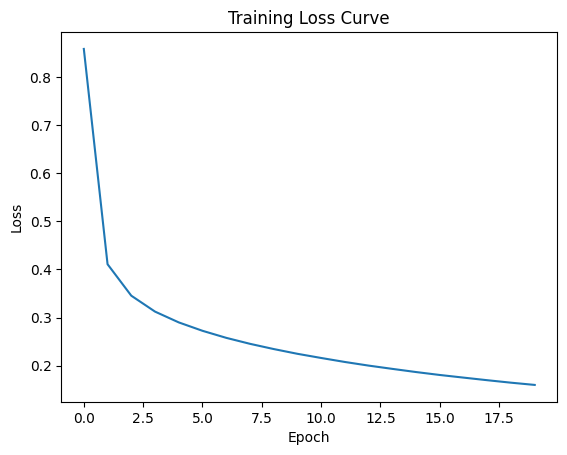

In [ ]:


(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalization

x_train = x_train / 255.0
x_test = x_test / 255.0

# Flatten images

x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

# One hot encoding

def one_hot(y, num_classes=10):

    encoded = np.zeros((y.size, num_classes))

    encoded[np.arange(y.size), y] = 1

    return encoded

y_train_encoded = one_hot(y_train)
y_test_encoded = one_hot(y_test)

# Network Architecture

input_size = 784
hidden_size = 128
output_size = 10

# He Initialization

W1 = np.random.randn(input_size, hidden_size) * np.sqrt(2 / input_size)

b1 = np.zeros((1, hidden_size))

W2 = np.random.randn(hidden_size, output_size) * np.sqrt(2 / hidden_size)

b2 = np.zeros((1, output_size))

# Activation Functions

def relu(x):

    return np.maximum(0, x)

def relu_derivative(x):

    return (x > 0).astype(float)

# Softmax

def softmax(x):

    x = x - np.max(x, axis=1, keepdims=True)

    exp_x = np.exp(x)

    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

#  Loss functions

def compute_loss(y_true, y_pred):

    m = y_true.shape[0]

    epsilon = 1e-15

    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)

    loss = -np.sum(y_true * np.log(y_pred)) / m

    return loss

# Training settings

epochs = 20
learning_rate = 0.01
batch_size = 64

losses = []

for epoch in range(epochs):


    indices = np.random.permutation(x_train.shape[0]) # shuffle

    x_train = x_train[indices]
    y_train_encoded = y_train_encoded[indices]
    y_train = y_train[indices]

    epoch_loss = 0


    for i in range(0, x_train.shape[0], batch_size):   # mini batch training

        X_batch = x_train[i:i+batch_size]

        y_batch = y_train_encoded[i:i+batch_size]

        # Forward pass

        Z1 = np.dot(X_batch, W1) + b1

        A1 = relu(Z1)

        Z2 = np.dot(A1, W2) + b2

        A2 = softmax(Z2)

        # Loss

        loss = compute_loss(y_batch, A2)

        epoch_loss += loss

        # backpropogation

        m = X_batch.shape[0]

        # Output Layer

        dZ2 = A2 - y_batch

        dW2 = (1/m) * np.dot(A1.T, dZ2)

        db2 = (1/m) * np.sum(dZ2, axis=0, keepdims=True)

        # Hidden Layer

        dA1 = np.dot(dZ2, W2.T)

        dZ1 = dA1 * relu_derivative(Z1)

        dW1 = (1/m) * np.dot(X_batch.T, dZ1)

        db1 = (1/m) * np.sum(dZ1, axis=0, keepdims=True)

        # update parameters

        W1 -= learning_rate * dW1
        b1 -= learning_rate * db1

        W2 -= learning_rate * dW2
        b2 -= learning_rate * db2

    # Full accuracy

    Z1_full = np.dot(x_train, W1) + b1

    A1_full = relu(Z1_full)

    Z2_full = np.dot(A1_full, W2) + b2

    A2_full = softmax(Z2_full)

    predictions = np.argmax(A2_full, axis=1)

    accuracy = np.mean(predictions == y_train)

    avg_loss = epoch_loss / (x_train.shape[0] // batch_size)

    losses.append(avg_loss)

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Loss     : {avg_loss:.4f}")
    print(f"Accuracy : {accuracy*100:.2f}%")
    print("------------------------------------------------")

# Test accuracy

Z1_test = np.dot(x_test, W1) + b1

A1_test = relu(Z1_test)

Z2_test = np.dot(A1_test, W2) + b2

A2_test = softmax(Z2_test)

test_predictions = np.argmax(A2_test, axis=1)

test_accuracy = np.mean(test_predictions == y_test)

print("\nFinal Test Accuracy :", test_accuracy * 100, "%")

# loss curve

plt.plot(losses)

plt.title("Training Loss Curve")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.show()

task 5

Final Test Accuracy : 95.37 %


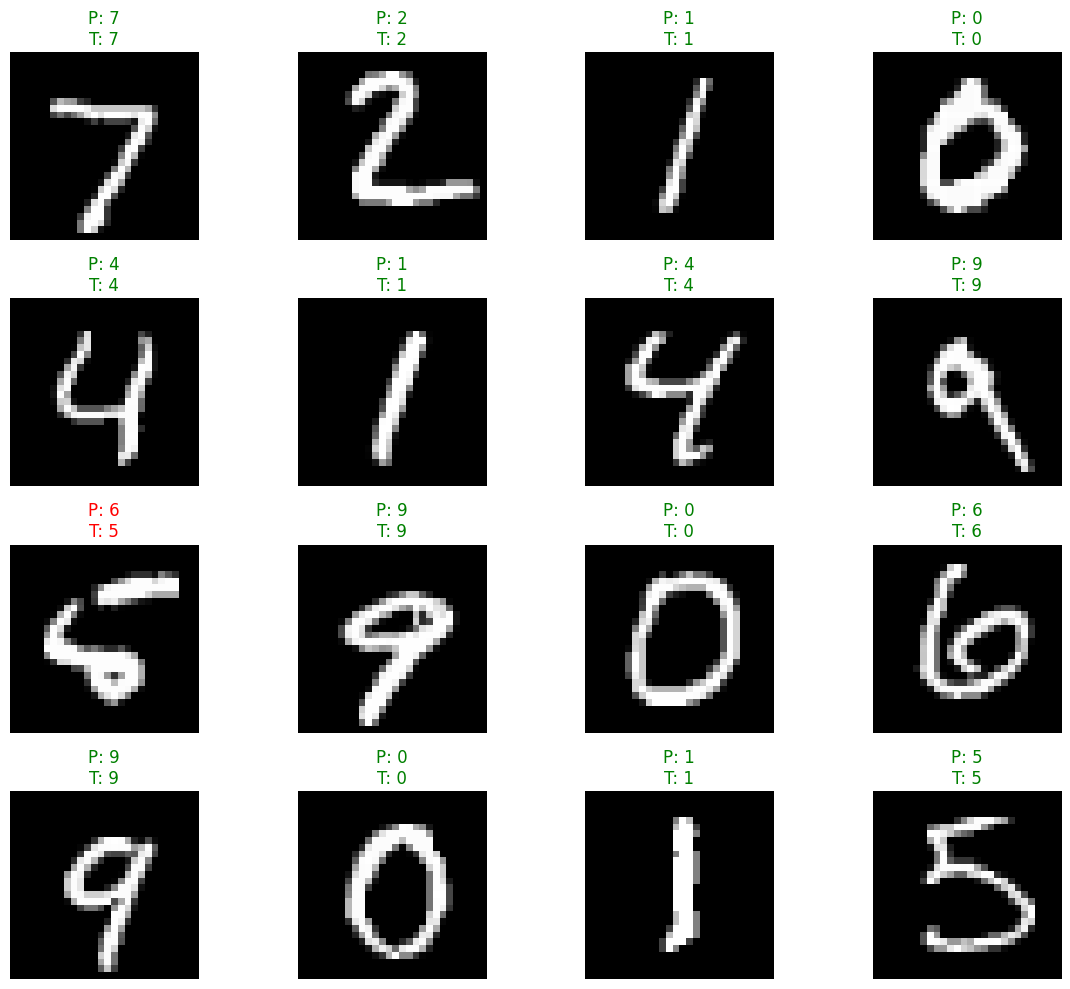

In [ ]:

# forward pass on test data

Z1_test = np.dot(x_test, W1) + b1

A1_test = relu(Z1_test)

Z2_test = np.dot(A1_test, W2) + b2

A2_test = softmax(Z2_test)

# Final prediction

predictions = np.argmax(A2_test, axis=1)

# test accuracy

accuracy = np.mean(predictions == y_test)

print("Final Test Accuracy :", accuracy * 100, "%")

# Display results

plt.figure(figsize=(12, 10))

for i in range(16):

    plt.subplot(4, 4, i + 1)

    # Reshape image back to 28x28

    image = x_test[i].reshape(28, 28)

    plt.imshow(image, cmap='gray')

    predicted_label = predictions[i]

    true_label = y_test[i]

# green if right, red if wrong

    if predicted_label == true_label:

        color = 'green'

    else:

        color = 'red'

    plt.title(
        f"P: {predicted_label}\nT: {true_label}",
        color=color
    )

    plt.axis('off')

plt.tight_layout()

plt.show()

In [64]:
total_params = W1.size + b1.size + W2.size + b2.size
print(f"Total Parameters: {total_params}") # Output: 101770

Total Parameters: 101770


In [ ]:
import time

epochs = 20
learning_rate = 0.01
batch_size = 64

losses = []


for epoch in range(epochs):
    start_time = time.time()

    indices = np.random.permutation(x_train.shape[0]) # shuffle

    x_train = x_train[indices]
    y_train_encoded = y_train_encoded[indices]
    y_train = y_train[indices]

    epoch_loss = 0


    for i in range(0, x_train.shape[0], batch_size):   # mini batch training

        X_batch = x_train[i:i+batch_size]

        y_batch = y_train_encoded[i:i+batch_size]

        # Forward pass

        Z1 = np.dot(X_batch, W1) + b1

        A1 = relu(Z1)

        Z2 = np.dot(A1, W2) + b2

        A2 = softmax(Z2)

        # Loss

        loss = compute_loss(y_batch, A2)

        epoch_loss += loss

        # backpropogation

        m = X_batch.shape[0]

        # Output Layer

        dZ2 = A2 - y_batch

        dW2 = (1/m) * np.dot(A1.T, dZ2)

        db2 = (1/m) * np.sum(dZ2, axis=0, keepdims=True)

        # Hidden Layer

        dA1 = np.dot(dZ2, W2.T)

        dZ1 = dA1 * relu_derivative(Z1)

        dW1 = (1/m) * np.dot(X_batch.T, dZ1)

        db1 = (1/m) * np.sum(dZ1, axis=0, keepdims=True)

        # update parameters

        W1 -= learning_rate * dW1
        b1 -= learning_rate * db1

        W2 -= learning_rate * dW2
        b2 -= learning_rate * db2
   
    # 2. Stopwatch Stop
    end_time = time.time()
    
    # 3. Time Difference Calculate
    epoch_duration = end_time - start_time
    
    # 4. Print statement format karna
    print(f"Epoch {epoch + 1}/{epochs} | Time Taken: {epoch_duration:.2f} seconds")

Epoch 1/20 | Time Taken: 1.11 seconds
Epoch 2/20 | Time Taken: 1.01 seconds
Epoch 3/20 | Time Taken: 1.08 seconds
Epoch 4/20 | Time Taken: 1.02 seconds
Epoch 5/20 | Time Taken: 0.87 seconds
Epoch 6/20 | Time Taken: 0.78 seconds
Epoch 7/20 | Time Taken: 0.75 seconds
Epoch 8/20 | Time Taken: 0.77 seconds
Epoch 9/20 | Time Taken: 0.77 seconds
Epoch 10/20 | Time Taken: 0.82 seconds
Epoch 11/20 | Time Taken: 0.75 seconds
Epoch 12/20 | Time Taken: 0.80 seconds
Epoch 13/20 | Time Taken: 0.77 seconds
Epoch 14/20 | Time Taken: 0.81 seconds
Epoch 15/20 | Time Taken: 0.79 seconds
Epoch 16/20 | Time Taken: 0.82 seconds
Epoch 17/20 | Time Taken: 0.77 seconds
Epoch 18/20 | Time Taken: 0.81 seconds
Epoch 19/20 | Time Taken: 0.75 seconds
Epoch 20/20 | Time Taken: 0.80 seconds
